In [1]:
!pip install google-play-scraper


from google_play_scraper import app, reviews_all
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import download
from wordcloud import WordCloud


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [2]:

# App ID
app_id = 'com.lenskart.app'


# Get all reviews
all_reviews = reviews_all(
    app_id,
    sleep_milliseconds=0,  # Optional, defaults to 0
    lang='en',             # Language of the reviews
    country='us'           # Country of the reviews
)

# Print the first 10 reviews
for review in all_reviews[:10]:
    print(f"Review: {review['content']}\n")

# This retrieves all reviews and prints the content of the first 10.


Review: Lenskart gave a fake commitment on the very first order. Unexpected from such so called BRAND

Review: very good

Review: Very disappointing experience. Promises and commitments are never met. Support team keeps assuring quick resolution but nothing actually happens. Please fix your system and deliver what you commit — customers lose trust when words don’t match actions.

Review: worst app no customer care support they are cancelling ordered products and giving coupons for compensation but no comparison of money

Review: very pathetic service, delivered other item than ordered items.

Review: good 👍

Review: Love it ❤️

Review: very good

Review: good

Review: Good



In [3]:

# Convert the list of reviews to a DataFrame
df = pd.DataFrame(all_reviews)

# Display the first few rows of the DataFrame
df.head()


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,550553c3-6514-4911-9ffb-137e9cf20f82,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Lenskart gave a fake commitment on the very fi...,1,0,5.2.6,2025-11-12 09:27:33,None,NaT,5.2.6
1,e14b2be9-9631-4bce-8c25-53395fbe0508,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,very good,5,0,5.2.6,2025-11-12 09:17:04,None,NaT,5.2.6
2,a7d48504-b621-4dfe-867f-89ae3bdbc0a4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Very disappointing experience. Promises and co...,1,0,5.2.6,2025-11-12 09:02:31,None,NaT,5.2.6
3,4c82dffd-df74-4ddb-b683-e09285cfecef,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,worst app no customer care support they are ca...,1,0,None,2025-11-12 08:48:00,None,NaT,None
4,4f1dd671-bf18-498c-8d2f-8dd08839788f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"very pathetic service, delivered other item th...",1,0,5.2.7,2025-11-12 07:42:09,None,NaT,5.2.7


In [4]:
df.shape

(162019, 11)

In [5]:


# Download NLTK resources if not already downloaded
download('stopwords')
download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ''
    # Lowercase the text
    text = text.lower()
    # Remove special characters except for spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = ' '.join(text.split())
    # Remove stop words
    text = ' '.join(word for word in text.split() if word not in stop_words)
    # Lemmatize words
    text = ' '.join(lemmatizer.lemmatize(word) for word in text.split())
    return text

# Clean the content column
df['cleaned_content'] = df['content'].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [6]:
df['cleaned_content'].head()

,cleaned_content
0,lenskart gave fake commitment first order unex...
1,good
2,disappointing experience promise commitment ne...
3,worst app customer care support cancelling ord...
4,pathetic service delivered item ordered item


In [7]:


def analyze_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Apply sentiment analysis to the cleaned content
df['content_sentiment'] = df['cleaned_content'].apply(analyze_sentiment)

# Classify sentiment based on polarity score
def classify_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['content_sentiment_class'] = df['content_sentiment'].apply(classify_sentiment)


In [8]:
df['content_sentiment_class'].tail()

,content_sentiment_class
162014,Positive
162015,Positive
162016,Positive
162017,Positive
162018,Positive


/tmp/ipython-input-1624769629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='content_sentiment_class', data=df, palette='viridis')


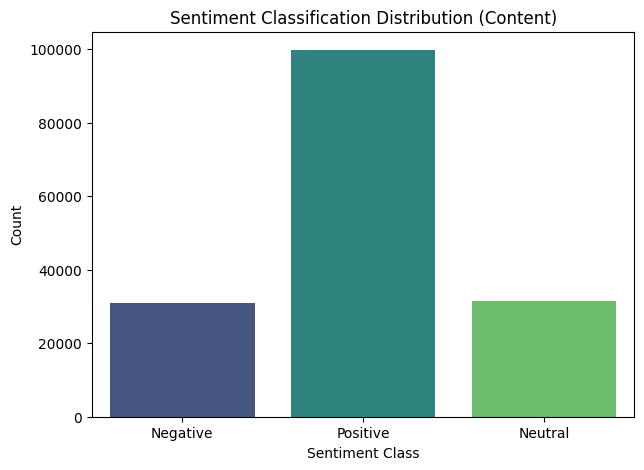

In [9]:


# Plot sentiment distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='content_sentiment_class', data=df, palette='viridis')
plt.title('Sentiment Classification Distribution (Content)')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()


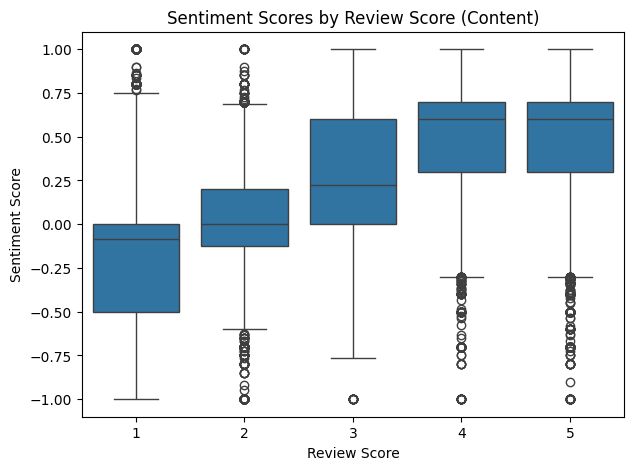

In [10]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='score', y='content_sentiment', data=df)
plt.title('Sentiment Scores by Review Score (Content)')
plt.xlabel('Review Score')
plt.ylabel('Sentiment Score')
plt.show()


/tmp/ipython-input-447221408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df, palette='viridis')


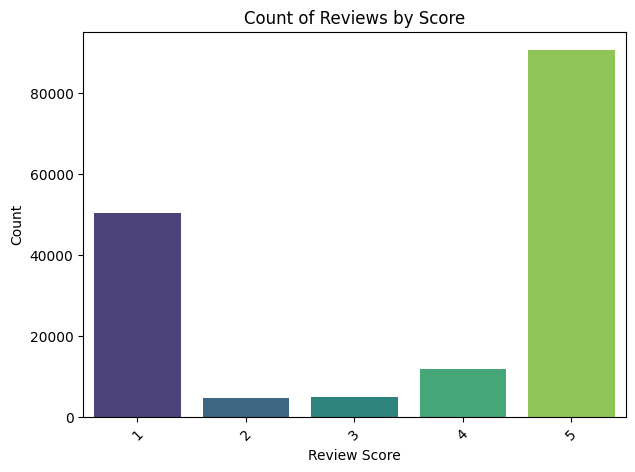

In [11]:
# Plot count of reviews by score
plt.figure(figsize=(7, 5))
sns.countplot(x='score', data=df, palette='viridis')
plt.title('Count of Reviews by Score')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

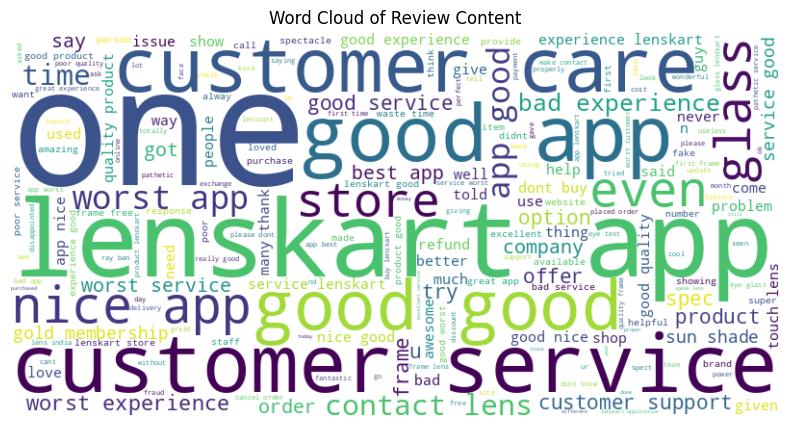

In [12]:


# Combine all the cleaned review content into a single text
text = ' '.join(df['cleaned_content'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide the axes
plt.title('Word Cloud of Review Content')
plt.show()



### TEXT CLASSIFICATION USING DECISION TREE AND RANDOM FOREST

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [14]:
#  Prepare Data

X = df['cleaned_content']
y = df['content_sentiment_class']

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

print(tfidf)

print(X_tfidf)

TfidfVectorizer(max_features=5000)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1093483 stored elements and shape (162019, 5000)>
  Coords	Values
  (0, 2610)	0.1609282528908835
  (0, 1886)	0.3497602855464255
  (0, 1656)	0.30956430094625426
  (0, 876)	0.40304154908512696
  (0, 1738)	0.27401920113808187
  (0, 3135)	0.21731518092990307
  (0, 4629)	0.5048928859342806
  (0, 671)	0.33873427377125287
  (0, 608)	0.31863325064618614
  (1, 1949)	1.0
  (2, 876)	0.20668394829408646
  (2, 1280)	0.20061015155638756
  (2, 1584)	0.10347976189478968
  (2, 3462)	0.1904065226423023
  (2, 2998)	0.1420826642338457
  (2, 2863)	0.2582697962585518
  (2, 4336)	0.14004597703066018
  (2, 4386)	0.1584563315570294
  (2, 2462)	0.15553301861657298
  (2, 341)	0.28844303474816624
  (2, 3524)	0.1912693110202389
  (2, 3744)	0.21431486433487498
  (2, 3037)	0.14653143436972935
  (2, 76)	0.17177621368363255
  (2, 2041)	0.2260176536155004
  :	:
  (162013, 3110)	0.18397302729503928
  (162013, 3190)	0.2089222

In [15]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (129615, 5000)
Test shape: (32404, 5000)


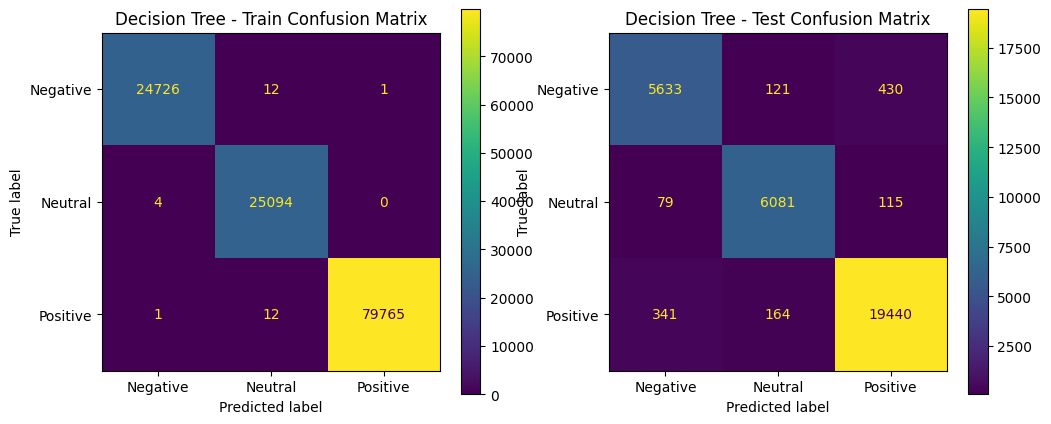

Decision Tree - Classification Report (Test):
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92      6184
     Neutral       0.96      0.97      0.96      6275
    Positive       0.97      0.97      0.97     19945

    accuracy                           0.96     32404
   macro avg       0.95      0.95      0.95     32404
weighted avg       0.96      0.96      0.96     32404



In [16]:
# Decision Tree Classifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_train_pred_dt), display_labels=dt.classes_).plot(ax=ax[0], cmap='viridis', values_format='d')
ax[0].set_title("Decision Tree - Train Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred_dt), display_labels=dt.classes_).plot(ax=ax[1], cmap='viridis', values_format='d')
ax[1].set_title("Decision Tree - Test Confusion Matrix")
plt.show()

print("Decision Tree - Classification Report (Test):")
print(classification_report(y_test, y_test_pred_dt))

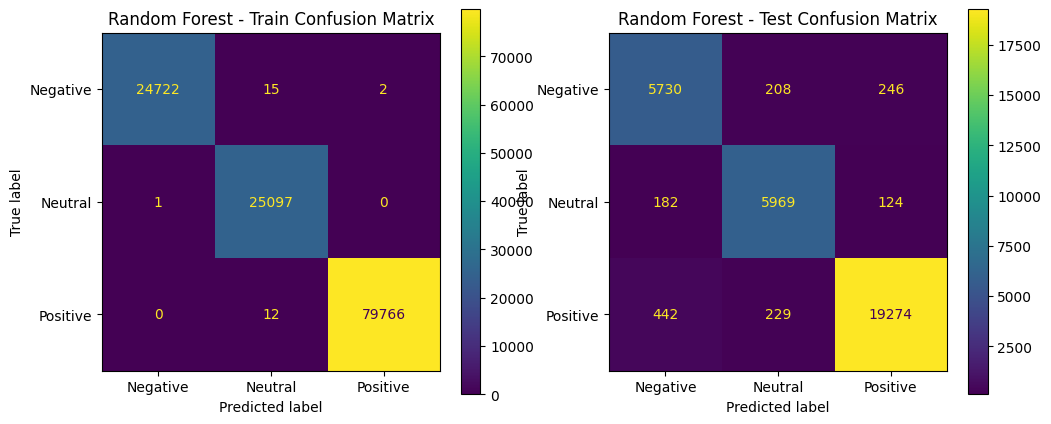

Random Forest - Classification Report (Test):
              precision    recall  f1-score   support

    Negative       0.90      0.93      0.91      6184
     Neutral       0.93      0.95      0.94      6275
    Positive       0.98      0.97      0.97     19945

    accuracy                           0.96     32404
   macro avg       0.94      0.95      0.94     32404
weighted avg       0.96      0.96      0.96     32404



In [17]:
#  Random Forest Classifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_train_pred_rf), display_labels=rf.classes_).plot(ax=ax[0], cmap='viridis', values_format='d')
ax[0].set_title("Random Forest - Train Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred_rf), display_labels=rf.classes_).plot(ax=ax[1], cmap='viridis', values_format='d')
ax[1].set_title("Random Forest - Test Confusion Matrix")
plt.show()

print("Random Forest - Classification Report (Test):")
print(classification_report(y_test, y_test_pred_rf))
